In [1]:
# [Setup]: 

# Ran the following in Anaconda Prompt:
# git clone https://github.com/burke86/deepdisc.git
# cd deepdisc
# conda create -n deepdisc python=3.10 -y
# conda activate deepdisc
# pip install setuptools==67.8.0
# pip install pybind11
# NOTE: scarlet skipped, does not compile on Windows (optional dependency, not needed for detection)

# Ran the following in Anaconda Prompt:
# nvidia-smi

# If Version CUDA is not 12.1, install older versions to be compatible with torch and relevant packages:
# Ran the following in Anaconda Prompt:
# conda activate deepdisc
# pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121

# Ran the following in Anaconda Prompt:
# pip install --no-build-isolation git+https://github.com/facebookresearch/detectron2.git
# mkdir taufit
# echo __version__ = "0.1.0" > taufit\version.py
# echo. > requirements.txt
# pip install --no-build-isolation -e .
# pip install --no-deps --no-build-isolation .
# pip install opencv-python
# pip install scikit-image
# pip install ipympl
# pip install ipywidgets
# pip install astropy photutils matplotlib pandas ipykernel astroquery
# python -m ipykernel install --user --name deepdisc --display-name "Python (deepdisc)"

# Now, in VSCodium, click top right for environment -> "Choose another Kernel" -> "deepdisc"

In [1]:
# ============================================================================
# 02_A_SiSaP.ipynb - Cell 1: RUN — processes V CrA only, saves output files.
# No plotting here — see Cell 2 for light curve generation from the
# resulting files.
# ============================================================================

from pathlib import Path
from datetime import datetime
import shelve
import time
import traceback
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from astropy.io import fits as astrofits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.stats import SigmaClip, sigma_clipped_stats, sigma_clip
import astropy.units as u
from photutils.aperture import (CircularAperture, CircularAnnulus,
                                 ApertureStats, aperture_photometry)
from photutils.centroids import centroid_sources, centroid_com
from photutils.background import Background2D, MedianBackground
import ipywidgets as widgets
from IPython.display import display
import urllib.request
import urllib.parse

# ============================================================================
# PATHS
# ============================================================================
BASE_DATA_DIR = Path(r"C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data")

RUN_ONLY_THESE_STARS = ["V_CrA"]  # set to None to process every star folder instead

star_dirs = sorted([d for d in BASE_DATA_DIR.iterdir()
                     if d.is_dir() and (d / 'cutouts').is_dir()])
if RUN_ONLY_THESE_STARS is not None:
    star_dirs = [d for d in star_dirs if d.name in RUN_ONLY_THESE_STARS]

print(f"Found {len(star_dirs)} star folder(s) with a cutouts/ directory:")
for d in star_dirs:
    n_fits = len(list((d / 'cutouts').glob('*.fits')))
    print(f"  {d.name}: {n_fits} plates")

SHARED_CACHE_DIR = Path(r"C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\_shared_Cache_03_A")
SHARED_CACHE_DIR.mkdir(parents=True, exist_ok=True)
apass_cache = shelve.open(str(SHARED_CACHE_DIR / 'apass_cache_shelf'), flag='c', writeback=False)
print(f"\nLoaded {len(apass_cache)} cached APASS field queries (shared across all stars)")

MANUAL_TARGET_COORDS = {
    'V_CrA': SkyCoord(ra=281.884623417 * u.deg, dec=-38.158974417 * u.deg),
}

TARGET_COORD_CACHE_PATH = SHARED_CACHE_DIR / 'target_coords.csv'

def resolve_target_coord(star_dir):
    """Get (and cache) the target coordinate for a star folder."""
    name = star_dir.name

    if name in MANUAL_TARGET_COORDS:
        return MANUAL_TARGET_COORDS[name], 'manual'

    if TARGET_COORD_CACHE_PATH.exists():
        cached = pd.read_csv(TARGET_COORD_CACHE_PATH)
        match = cached[cached['folder_name'] == name]
        if len(match) > 0:
            row = match.iloc[0]
            return SkyCoord(ra=row['ra_deg'] * u.deg, dec=row['dec_deg'] * u.deg), 'cached'

    query_name = name.replace('_', ' ')
    try:
        coord = SkyCoord.from_name(query_name)
        row = pd.DataFrame([{'folder_name': name, 'query_name': query_name,
                              'ra_deg': coord.ra.deg, 'dec_deg': coord.dec.deg}])
        if TARGET_COORD_CACHE_PATH.exists():
            row.to_csv(TARGET_COORD_CACHE_PATH, mode='a', header=False, index=False)
        else:
            row.to_csv(TARGET_COORD_CACHE_PATH, index=False)
        return coord, 'resolved'
    except Exception as e:
        return None, f'FAILED: {e}'

# ============================================================================
# PHOTOMETRY PARAMETERS
# ============================================================================
DEFAULT_APERTURE = 6
ANNULUS_INNER = 15
ANNULUS_OUTER = 20
CENTROID_BOX = 21
CENTROID_MAX_DRIFT = 5
SIGNIF_THRESHOLD = 5.0
SATURATION_FRACTION = 0.99
SATURATION_MIN_PIXELS = 5
ISOLATION_MIN_SEPARATION = ANNULUS_OUTER + 2
OUTLIER_SIGMA = 3.0
REF_STARS_MAX_PER_PLATE = 150

MIN_REF_STARS = 25
LOCAL_HALF_WINDOW = 1.5
MIN_REF_STARS_LOCAL = 8
LOCAL_WINDOW_GROWTH = 1.6

MAX_CALIBRATION_RMS = 0.5

PIPELINE_VERSION = 1
MIN_APASS_STARS_QUERY = 10

# ============================================================================
# CORE PHOTOMETRY FUNCTIONS
# ============================================================================

def subtract_background_2d(data, box_size=50):
    try:
        bkg = Background2D(data, (box_size, box_size), filter_size=(3, 3),
                            bkg_estimator=MedianBackground())
        return data - bkg.background, bkg.background_rms
    except Exception:
        med = np.nanmedian(data)
        return data - med, np.full_like(data, np.nanstd(data))

def refine_centroids(data, x, y, box_size=CENTROID_BOX, max_drift=CENTROID_MAX_DRIFT):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) == 0:
        return x, y
    try:
        x_ref, y_ref = centroid_sources(data, x, y, box_size=box_size,
                                         centroid_func=centroid_com)
        good = np.isfinite(x_ref) & np.isfinite(y_ref)
        drift = np.hypot(x_ref - x, y_ref - y)
        good &= drift < max_drift
        x_ref[~good] = x[~good]
        y_ref[~good] = y[~good]
        return x_ref, y_ref
    except Exception:
        return x, y

def filter_isolated_stars(x, y, min_separation=ISOLATION_MIN_SEPARATION):
    n = len(x)
    if n < 2:
        return np.ones(n, dtype=bool)
    isolated = np.ones(n, dtype=bool)
    for i in range(n):
        d = np.hypot(x - x[i], y - y[i])
        d[i] = np.inf
        if np.any(d < min_separation):
            isolated[i] = False
    return isolated

def measure_aperture_photometry(data, x, y, radius=DEFAULT_APERTURE,
                                 annulus_inner=ANNULUS_INNER, annulus_outer=ANNULUS_OUTER):
    n = len(x)
    if n == 0:
        return np.array([]), np.array([]), np.array([])
    positions = list(zip(x, y))
    aperture = CircularAperture(positions, r=radius)
    annulus = CircularAnnulus(positions, r_in=annulus_inner, r_out=annulus_outer)
    ann_stats = ApertureStats(data, annulus, sigma_clip=SigmaClip(sigma=3.0))
    bkg_median = np.nan_to_num(ann_stats.median, nan=0.0)
    bkg_std = np.nan_to_num(ann_stats.std, nan=0.0)
    phot = aperture_photometry(data, aperture)
    flux = phot['aperture_sum'].value - bkg_median * (np.pi * radius**2)
    return flux, bkg_median, bkg_std

def detect_saturation(data, x, y, radius=DEFAULT_APERTURE,
                       sat_fraction=SATURATION_FRACTION, min_pixels=SATURATION_MIN_PIXELS):
    n = len(x)
    is_sat = np.zeros(n, dtype=bool)
    data_max = np.nanmax(data)
    if data_max <= 0:
        return is_sat
    positions = list(zip(x, y))
    aperture = CircularAperture(positions, r=radius)
    aperture_masks = aperture.to_mask(method='center')
    for i in range(n):
        mask = aperture_masks[i]
        cut = mask.multiply(data)
        if cut is None:
            continue
        star_pixels = cut[mask.data > 0]
        if len(star_pixels) == 0:
            continue
        near_max = np.sum(star_pixels >= sat_fraction * data_max)
        is_sat[i] = near_max >= min_pixels
    return is_sat

def calibrate_global(inst_mags, apass_b, outlier_sigma=OUTLIER_SIGMA, min_stars=MIN_REF_STARS):
    mask = np.isfinite(inst_mags) & np.isfinite(apass_b)
    if mask.sum() < min_stars:
        return None
    x = apass_b[mask]
    y = inst_mags[mask]
    for _ in range(3):
        try:
            coeffs = np.polyfit(x, y, 2)
            residuals = y - np.polyval(coeffs, x)
            rms = np.sqrt(np.mean(residuals**2))
            good = np.abs(residuals) < outlier_sigma * rms
            if good.sum() < min_stars:
                break
            x, y = x[good], y[good]
        except Exception:
            return None
    if len(x) < min_stars:
        return None
    coeffs = np.polyfit(x, y, 2)
    residuals = y - np.polyval(coeffs, x)
    rms = np.sqrt(np.mean(residuals**2))
    return {'coeffs': coeffs, 'rms': rms, 'n_used': len(x),
            'b_min': float(np.min(x)), 'b_max': float(np.max(x))}

def calibrate_local(inst_mags, apass_b, target_b_estimate,
                     half_window=LOCAL_HALF_WINDOW, min_stars=MIN_REF_STARS_LOCAL,
                     growth=LOCAL_WINDOW_GROWTH, outlier_sigma=OUTLIER_SIGMA):
    mask = np.isfinite(inst_mags) & np.isfinite(apass_b)
    x_all, y_all = apass_b[mask], inst_mags[mask]
    if len(x_all) < min_stars:
        return None
    window = half_window
    local_mask = np.abs(x_all - target_b_estimate) <= window
    for _ in range(5):
        if local_mask.sum() >= min_stars:
            break
        window *= growth
        local_mask = np.abs(x_all - target_b_estimate) <= window
    if local_mask.sum() < min_stars:
        return None
    x, y = x_all[local_mask], y_all[local_mask]
    for _ in range(3):
        try:
            coeffs = np.polyfit(x, y, 1)
            residuals = y - np.polyval(coeffs, x)
            rms = np.sqrt(np.mean(residuals**2))
            good = np.abs(residuals) < outlier_sigma * rms
            if good.sum() < min_stars:
                break
            x, y = x[good], y[good]
        except Exception:
            return None
    if len(x) < min_stars:
        return None
    coeffs = np.polyfit(x, y, 1)
    residuals = y - np.polyval(coeffs, x)
    rms = np.sqrt(np.mean(residuals**2))
    return {'coeffs': coeffs, 'rms': rms, 'n_used': len(x),
            'window_used': float(window),
            'b_min': float(np.min(x)), 'b_max': float(np.max(x))}

def invert_calibration(calibration, t_inst_mag):
    coeffs = calibration['coeffs']
    poly = list(coeffs)
    poly[-1] = poly[-1] - t_inst_mag
    roots = np.roots(poly)
    real_roots = roots[np.abs(roots.imag) < 1e-6].real
    if len(real_roots) == 0:
        return None
    lo, hi = calibration['b_min'], calibration['b_max']
    in_range = real_roots[(real_roots >= lo - 2) & (real_roots <= hi + 2)]
    candidates = in_range if len(in_range) > 0 else real_roots
    best = min(candidates, key=lambda r: abs(np.polyval(coeffs, r) - t_inst_mag))
    return float(best)

def query_apass(ra_c, dec_c, radius_arcsec, max_rows=3000):
    params = {
        '-source': 'II/336/apass9',
        '-c': f"{ra_c} {dec_c}",
        '-c.rs': radius_arcsec,
        '-out': 'RAJ2000,DEJ2000,Bmag,e_Bmag',
        '-out.max': max_rows,
    }
    url = "https://vizier.cds.unistra.fr/viz-bin/asu-tsv?" + urllib.parse.urlencode(params)
    for attempt in range(3):
        try:
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=30) as response:
                return response.read().decode('utf-8')
        except Exception:
            time.sleep(2 ** attempt)
    return None

def parse_apass_tsv(text):
    rows = []
    for line in text.split('\n'):
        line = line.strip()
        if not line or line.startswith('#') or line.startswith('-'):
            continue
        parts = line.split('\t')
        if len(parts) < 4:
            continue
        try:
            ra, dec, bmag, e_bmag = float(parts[0]), float(parts[1]), float(parts[2]), float(parts[3])
            rows.append((ra, dec, bmag, e_bmag))
        except (ValueError, IndexError):
            continue
    if rows and not (0 < rows[0][2] < 25):
        rows = rows[1:]
    return rows

def get_field_catalog(ra_c, dec_c, radius_arcsec):
    key = f"{round(ra_c, 3)}_{round(dec_c, 3)}"
    if key in apass_cache:
        return apass_cache[key]
    raw = query_apass(ra_c, dec_c, radius_arcsec)
    rows = []
    if raw:
        rows = parse_apass_tsv(raw)
        rows = [r for r in rows if 0 < r[2] < 20 and r[3] < 0.5]
    apass_cache[key] = rows
    return rows

def get_plate_jd(header):
    if 'JD-OBS' in header:
        return float(header['JD-OBS'])
    if 'MJD-OBS' in header:
        return float(header['MJD-OBS']) + 2400000.5
    for key in ('DATE-OBS', 'DATE'):
        if key in header:
            try:
                return Time(header[key]).jd
            except Exception:
                continue
    return np.nan


# ============================================================================
# PER-PLATE PROCESSING
# ============================================================================

def process_plate(fits_path, target_coord):
    try:
        data = astrofits.getdata(fits_path).astype(float)
        header = astrofits.getheader(fits_path)
        wcs = WCS(header)
        jd = get_plate_jd(header)
        data_sub, bkg_rms = subtract_background_2d(data)

        h, w = data.shape
        ra_c, dec_c = wcs.all_pix2world(w / 2, h / 2, 0)
        corners_x = [0, w - 1, 0, w - 1]
        corners_y = [0, 0, h - 1, h - 1]
        corner_ra, corner_dec = wcs.all_pix2world(corners_x, corners_y, 0)
        center = SkyCoord(float(ra_c) * u.deg, float(dec_c) * u.deg)
        corners_sky = SkyCoord(corner_ra * u.deg, corner_dec * u.deg)
        field_radius_arcsec = center.separation(corners_sky).max().arcsec * 1.05

        apass_stars = get_field_catalog(float(ra_c), float(dec_c), field_radius_arcsec)
        if len(apass_stars) < MIN_APASS_STARS_QUERY:
            return _empty_result(fits_path, jd, 'Too few APASS stars in field')

        ra = np.array([s[0] for s in apass_stars])
        dec = np.array([s[1] for s in apass_stars])
        apass_b = np.array([s[2] for s in apass_stars])

        x, y = wcs.all_world2pix(ra, dec, 0)
        margin = 20
        in_frame = (x > margin) & (x < w - margin) & (y > margin) & (y < h - margin)
        x, y, apass_b = x[in_frame], y[in_frame], apass_b[in_frame]
        star_ids = np.array([f'APASS_{i:05d}' for i in range(len(x))])

        if len(x) > REF_STARS_MAX_PER_PLATE:
            keep = np.random.choice(len(x), size=REF_STARS_MAX_PER_PLATE, replace=False)
            x, y, apass_b, star_ids = x[keep], y[keep], apass_b[keep], star_ids[keep]

        if len(x) == 0:
            return _empty_result(fits_path, jd, 'No APASS stars in frame')

        x_ref, y_ref = refine_centroids(data_sub, x, y)
        isolated = filter_isolated_stars(x_ref, y_ref)
        flux, bkg_med, bkg_std = measure_aperture_photometry(data_sub, x_ref, y_ref)

        area = np.pi * DEFAULT_APERTURE**2
        with np.errstate(divide='ignore', invalid='ignore'):
            snr = np.where(bkg_std > 0, flux / (bkg_std * np.sqrt(area)), 0)

        is_sat = detect_saturation(data, x_ref, y_ref)
        with np.errstate(divide='ignore', invalid='ignore'):
            inst_mag = np.where(flux > 0, -2.5 * np.log10(np.maximum(flux, 1e-10)), np.nan)

        good_for_fit = (snr >= SIGNIF_THRESHOLD) & np.isfinite(inst_mag) & ~is_sat & isolated
        fit_inst_mag = inst_mag[good_for_fit]
        fit_apass_b = apass_b[good_for_fit]

        calibration_global = calibrate_global(fit_inst_mag, fit_apass_b)
        n_ref_used = calibration_global['n_used'] if calibration_global else int(good_for_fit.sum())

        ref_rows = []
        for i in range(len(x_ref)):
            if np.isfinite(inst_mag[i]) and snr[i] >= SIGNIF_THRESHOLD and isolated[i]:
                ref_rows.append({
                    'filename': fits_path.name,
                    'star_id': star_ids[i],
                    'apass_b_mag': apass_b[i],
                    'instrumental_mag': inst_mag[i]
                })

        tx, ty = wcs.all_world2pix(target_coord.ra.deg, target_coord.dec.deg, 0)
        target_detected = False
        target_mag = np.nan
        target_mag_error = np.nan
        calibration_mode = None
        final_rms = np.nan
        final_n_used = 0

        if margin < tx < w - margin and margin < ty < h - margin:
            tx_ref, ty_ref = refine_centroids(data_sub, np.array([tx]), np.array([ty]))
            t_flux, t_bkg_med, t_bkg_std = measure_aperture_photometry(data_sub, tx_ref, ty_ref)
            t_area = np.pi * DEFAULT_APERTURE**2
            t_snr = t_flux[0] / (t_bkg_std[0] * np.sqrt(t_area)) if t_bkg_std[0] > 0 else 0

            if t_snr >= SIGNIF_THRESHOLD and t_flux[0] > 0 and calibration_global is not None:
                t_inst_mag = -2.5 * np.log10(t_flux[0])
                rough_mag = invert_calibration(calibration_global, t_inst_mag)

                if rough_mag is not None:
                    calibration_local = calibrate_local(fit_inst_mag, fit_apass_b, rough_mag)
                    if calibration_local is not None:
                        local_mag = invert_calibration(calibration_local, t_inst_mag)
                        if local_mag is not None:
                            target_mag = local_mag
                            final_rms = calibration_local['rms']
                            final_n_used = calibration_local['n_used']
                            calibration_mode = 'local'
                    if calibration_mode is None:
                        target_mag = rough_mag
                        final_rms = calibration_global['rms']
                        final_n_used = calibration_global['n_used']
                        calibration_mode = 'global_fallback'

                    calibration_uncertainty = final_rms / np.sqrt(max(final_n_used, 1))
                    target_mag_error = np.sqrt((1.0857 / max(t_snr, 1e-6))**2 + calibration_uncertainty**2)
                    target_detected = True

                tx_out, ty_out = float(tx_ref[0]), float(ty_ref[0])
            else:
                tx_out, ty_out = float(tx_ref[0]), float(ty_ref[0])
        else:
            tx_out, ty_out = np.nan, np.nan

        quality_ok = (
            calibration_global is not None and
            n_ref_used >= MIN_REF_STARS and
            target_detected and
            np.isfinite(final_rms) and
            final_rms <= MAX_CALIBRATION_RMS
        )

        rejection_reason = None
        if calibration_global is None:
            rejection_reason = 'Global calibration failed (insufficient good reference stars)'
        elif n_ref_used < MIN_REF_STARS:
            rejection_reason = f'Too few reference stars in fit ({n_ref_used} < {MIN_REF_STARS})'
        elif not target_detected:
            rejection_reason = 'Target not detected'
        elif np.isfinite(final_rms) and final_rms > MAX_CALIBRATION_RMS:
            rejection_reason = f'Calibration RMS too high ({final_rms:.3f} > {MAX_CALIBRATION_RMS}, mode={calibration_mode})'

        result_row = {
            'filename': fits_path.name,
            'jd': jd,
            'target_detected': target_detected,
            'target_mag': target_mag,
            'target_mag_error': target_mag_error,
            'target_x': tx_out,
            'target_y': ty_out,
            'num_reference_stars': n_ref_used,
            'zeropoint': calibration_global['coeffs'][-1] if calibration_global else np.nan,
            'rms_scatter': final_rms,
            'rms_scatter_global': calibration_global['rms'] if calibration_global else np.nan,
            'calibration_mode': calibration_mode,
            'quality_ok': quality_ok,
            'rejection_reason': rejection_reason,
        }
        return {'result_row': result_row, 'ref_rows': ref_rows}

    except Exception as e:
        return _empty_result(fits_path, np.nan, str(e))

def _empty_result(fits_path, jd, reason):
    return {
        'result_row': {
            'filename': fits_path.name, 'jd': jd, 'target_detected': False,
            'target_mag': np.nan, 'target_mag_error': np.nan,
            'target_x': np.nan, 'target_y': np.nan,
            'num_reference_stars': 0, 'zeropoint': np.nan,
            'rms_scatter': np.nan, 'rms_scatter_global': np.nan,
            'calibration_mode': None, 'quality_ok': False,
            'rejection_reason': reason,
        },
        'ref_rows': [],
    }


# ============================================================================
# PER-STAR RUNNER
# ============================================================================

def format_eta(seconds):
    if seconds is None or seconds != seconds or seconds < 0:
        return "calculating..."
    m, s = divmod(int(seconds), 60)
    h, m = divmod(m, 60)
    return f"{h:d}:{m:02d}:{s:02d}" if h else f"{m:d}:{s:02d}"

def run_star(star_dir, target_coord, plate_progress_bar, plate_progress_html, plate_status_label):
    star_cutouts_dir = star_dir / 'cutouts'
    star_output_dir = star_dir / '02_A'
    star_output_dir.mkdir(parents=True, exist_ok=True)
    star_cache_dir = star_output_dir / 'algorithm_cache'
    star_cache_dir.mkdir(parents=True, exist_ok=True)

    results_path = star_output_dir / 'photometry_results.csv'
    lightcurve_path = star_output_dir / 'lightcurve.csv'
    ref_photometry_path = star_output_dir / 'reference_photometry.csv'

    cutouts = sorted(star_cutouts_dir.glob('*.fits'))
    total = max(len(cutouts), 1)
    plate_progress_bar.max = total
    plate_progress_bar.value = 0

    plate_db = shelve.open(str(star_cache_dir / 'plate_db_shelf'), flag='c', writeback=False)

    start = time.monotonic()
    last_render = 0.0
    n_errors = 0

    for i, f in enumerate(cutouts):
        key = str(f)
        cached = plate_db.get(key)
        if cached and cached.get('_version', 0) == PIPELINE_VERSION:
            pass
        else:
            plate_status_label.value = f"{star_dir.name}: {f.name}"
            out = process_plate(f, target_coord)
            if out['result_row'].get('num_reference_stars', 0) == 0:
                n_errors += 1
            out['_version'] = PIPELINE_VERSION
            plate_db[key] = out

        now = time.monotonic()
        if now - last_render > 0.15 or (i + 1) == total:
            elapsed = now - start
            pct = (i + 1) / total * 100
            rate = (i + 1) / elapsed if elapsed > 0 else 0
            remaining = (total - i - 1) / rate if rate > 0 else None
            plate_progress_bar.value = i + 1
            plate_progress_html.value = (
                f"<div style='font-family: monospace; font-size: 12px;'>"
                f"<b>{pct:5.1f}%</b> &nbsp; {i+1:,}/{total:,} plates &nbsp;|&nbsp; "
                f"{rate:.2f} plates/sec &nbsp;|&nbsp; "
                f"Elapsed {format_eta(elapsed)} &nbsp;|&nbsp; ETA {format_eta(remaining)}"
                f"</div>"
            )
            last_render = now

        if (i + 1) % 50 == 0:
            plate_db.sync()

    plate_db.sync()

    result_rows, ref_rows_all = [], []
    for f_str in plate_db.keys():
        out = plate_db[f_str]
        if out is None:
            continue
        result_rows.append(out['result_row'])
        ref_rows_all.extend(out['ref_rows'])

    results_df = pd.DataFrame(result_rows).sort_values('jd').reset_index(drop=True)
    results_df.to_csv(results_path, index=False)

    ref_df = pd.DataFrame(ref_rows_all)
    ref_df.to_csv(ref_photometry_path, index=False)

    lc_df = results_df[results_df['quality_ok']].copy()
    lc_df = lc_df.rename(columns={'target_mag': 'magnitude', 'target_mag_error': 'magnitude_error'})
    lc_df = lc_df[['jd', 'magnitude', 'magnitude_error']].dropna().sort_values('jd').reset_index(drop=True)

    n_before_clip = len(lc_df)
    if len(lc_df) > 20:
        window = 15
        rolling_med = lc_df['magnitude'].rolling(window, center=True, min_periods=5).median()
        residual = lc_df['magnitude'] - rolling_med
        clipped = sigma_clip(residual, sigma=4, maxiters=3)
        lc_df = lc_df[~clipped.mask].reset_index(drop=True)
    n_after_clip = len(lc_df)

    lc_df.to_csv(lightcurve_path, index=False)
    plate_db.close()

    return {
        'star': star_dir.name,
        'n_plates': len(results_df),
        'n_errors': n_errors,
        'n_lightcurve_points': n_after_clip,
        'n_removed_by_clip': n_before_clip - n_after_clip,
        'output_dir': str(star_output_dir),
    }


# ============================================================================
# RUN (no plotting — see Cell 2 for light curve generation)
# ============================================================================

overall_progress_bar = widgets.IntProgress(value=0, min=0, max=len(star_dirs), description='Stars:')
overall_status_label = widgets.Label(value="Not started")
plate_progress_bar = widgets.IntProgress(value=0, min=0, max=1, description='Plates:')
plate_progress_html = widgets.HTML(value="")
plate_status_label = widgets.Label(value="")

display(widgets.VBox([
    widgets.HTML("<b>Overall progress</b>"),
    widgets.HBox([overall_progress_bar, overall_status_label]),
    widgets.HTML("<b>Current star's plate progress</b>"),
    plate_progress_bar,
    plate_progress_html,
    plate_status_label,
]))

run_summaries = []
unresolved_stars = []

for i, star_dir in enumerate(star_dirs):
    overall_status_label.value = f"Resolving target for {star_dir.name}..."
    target_coord, coord_source = resolve_target_coord(star_dir)

    if target_coord is None:
        print(f"Could not resolve target coordinate for {star_dir.name} ({coord_source}) — skipping. "
              f"Add it to MANUAL_TARGET_COORDS above and rerun.")
        unresolved_stars.append(star_dir.name)
        overall_progress_bar.value = i + 1
        continue

    overall_status_label.value = f"Processing {star_dir.name} ({i+1}/{len(star_dirs)}), coord source: {coord_source}"

    try:
        summary = run_star(star_dir, target_coord, plate_progress_bar, plate_progress_html, plate_status_label)
        run_summaries.append(summary)
        print(f"{star_dir.name}: {summary['n_plates']} plates processed, "
              f"{summary['n_lightcurve_points']} light curve points -> {summary['output_dir']}")
    except Exception as e:
        print(f"ERROR processing {star_dir.name}: {e}")
        traceback.print_exc()

    apass_cache.sync()
    overall_progress_bar.value = i + 1

overall_status_label.value = f"Done. Processed {len(run_summaries)} / {len(star_dirs)} stars."
apass_cache.sync()

print("\n" + "=" * 70)
print("RUN SUMMARY")
print("=" * 70)
summary_df = pd.DataFrame(run_summaries)
if len(summary_df) > 0:
    print(summary_df.to_string(index=False))
if unresolved_stars:
    print(f"\nSkipped (coordinate resolution failed): {unresolved_stars}")
    print("  Add these to MANUAL_TARGET_COORDS at the top of this cell and rerun.")

Found 1 star folder(s) with a cutouts/ directory:
  V_CrA: 5405 plates

Loaded 0 cached APASS field queries (shared across all stars)


ERROR processing V_CrA: pickle data was truncated

RUN SUMMARY


Traceback (most recent call last):
  File "C:\Users\dapur\AppData\Local\Python\pythoncore-3.14-64\Lib\shelve.py", line 111, in __getitem__
    value = self.cache[key]
            ~~~~~~~~~~^^^^^
KeyError: 'C:\\Users\\dapur\\Downloads\\Other\\Research\\rcb_Star_Dust_Survey\\data\\V_CrA\\cutouts\\01635_am13688m1s0.fits'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "C:\Users\dapur\AppData\Local\Temp\ipykernel_26796\3095609481.py", line 640, in <module>
    summary = run_star(star_dir, target_coord, plate_progress_bar, plate_progress_html, plate_status_label)
  File "C:\Users\dapur\AppData\Local\Temp\ipykernel_26796\3095609481.py", line 566, in run_star
    out = plate_db[f_str]
          ~~~~~~~~^^^^^^^
  File "C:\Users\dapur\AppData\Local\Python\pythoncore-3.14-64\Lib\shelve.py", line 114, in __getitem__
    value = Unpickler(f).load()
_pickle.UnpicklingError: pickle data was truncated


Found 14 star folders. Generating comparison plots...
Opened DASCH session at disk location `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\R_CrB`
- Query target: `R CrB`
- Refcat: 405 sources from `apass`
- Exposures: 15217 relevant exposures


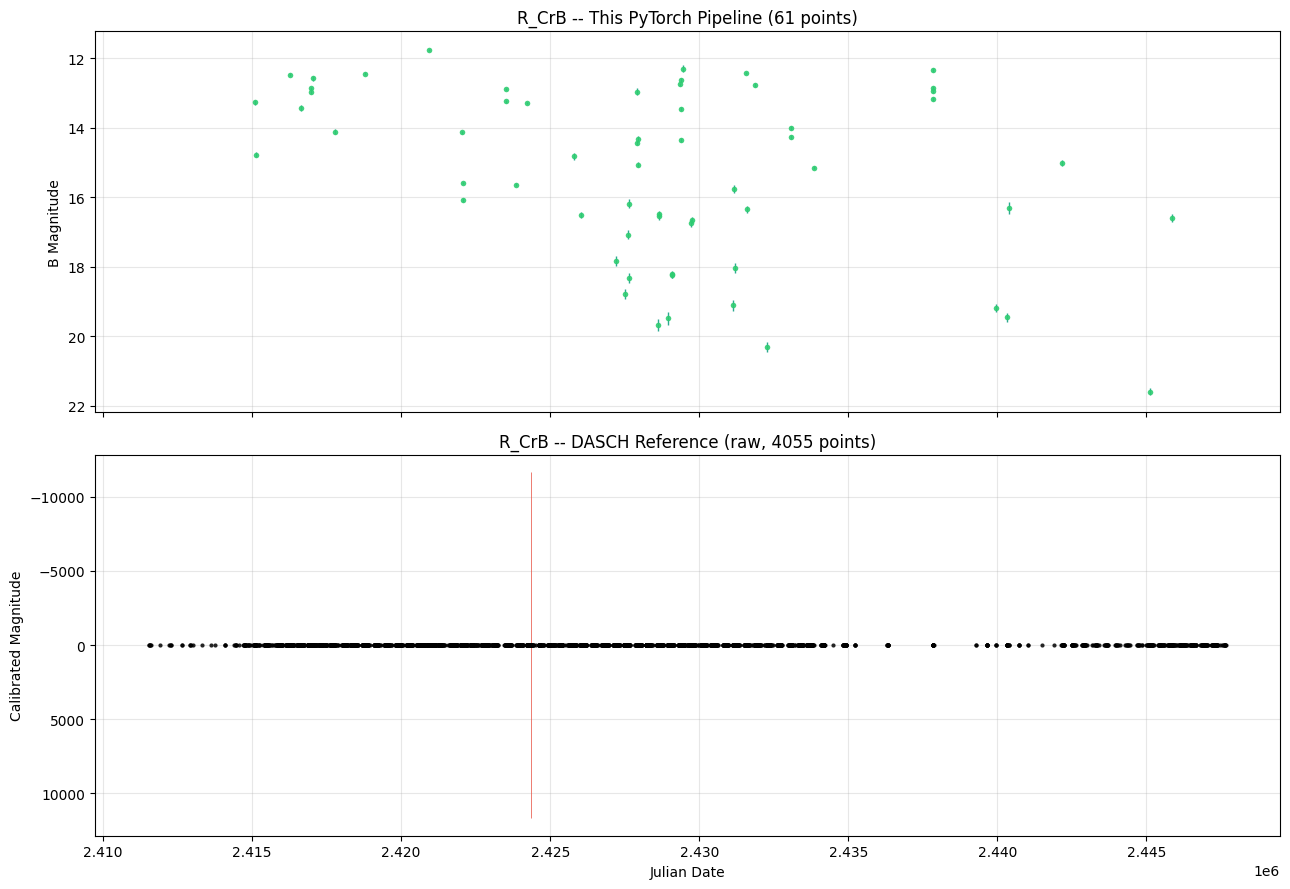

  R_CrB target-location tier breakdown:
target_location_tier
apass_list    10555
Opened DASCH session at disk location `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\RS_Tel`
- Query target: `RS Tel`
- Refcat: 9323 sources from `apass`
- Exposures: 6686 relevant exposures


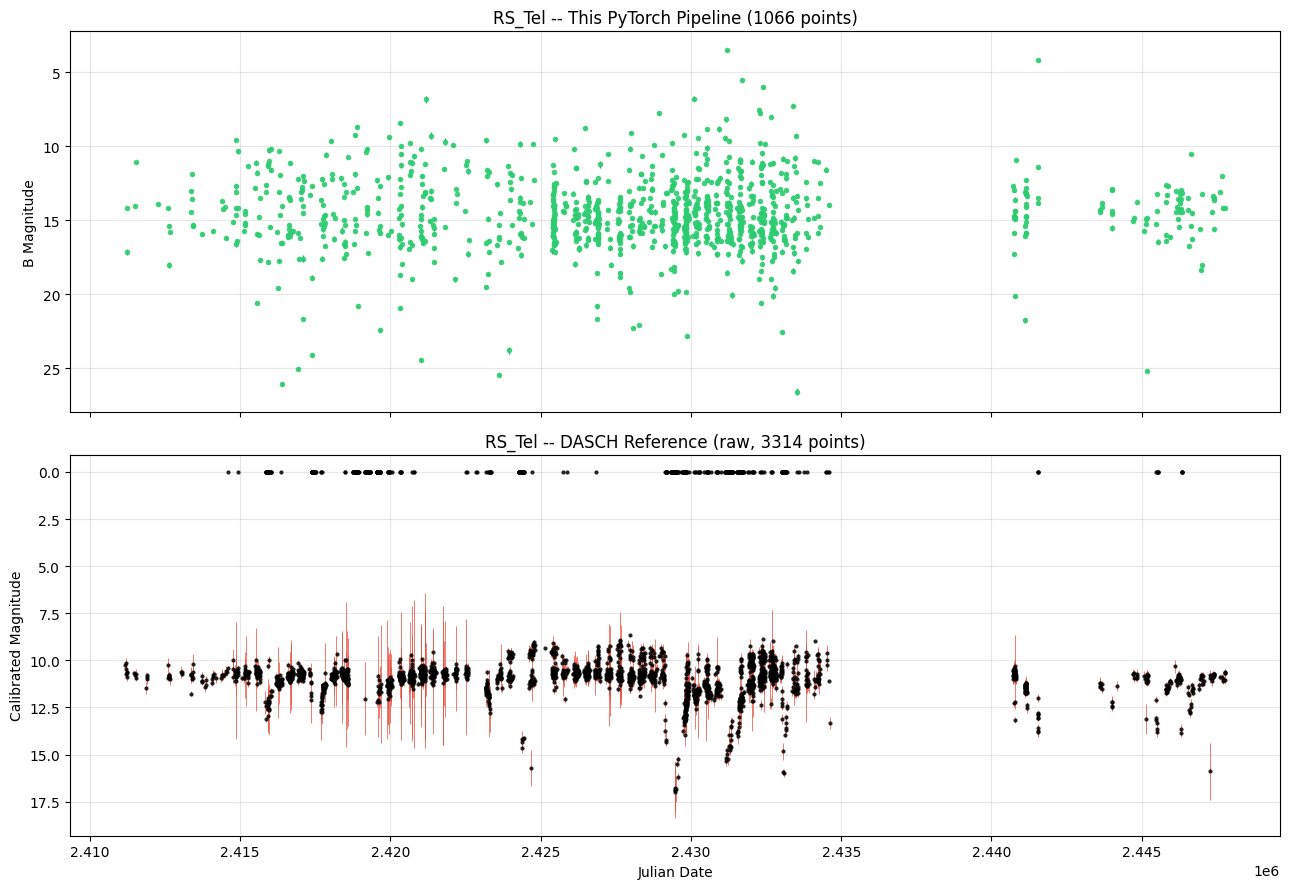

  RS_Tel target-location tier breakdown:
target_location_tier
apass_list    5265
Opened DASCH session at disk location `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\RY_Sgr`
- Query target: `RY Sgr`
- Refcat: 4051 sources from `apass`
- Exposures: 9215 relevant exposures


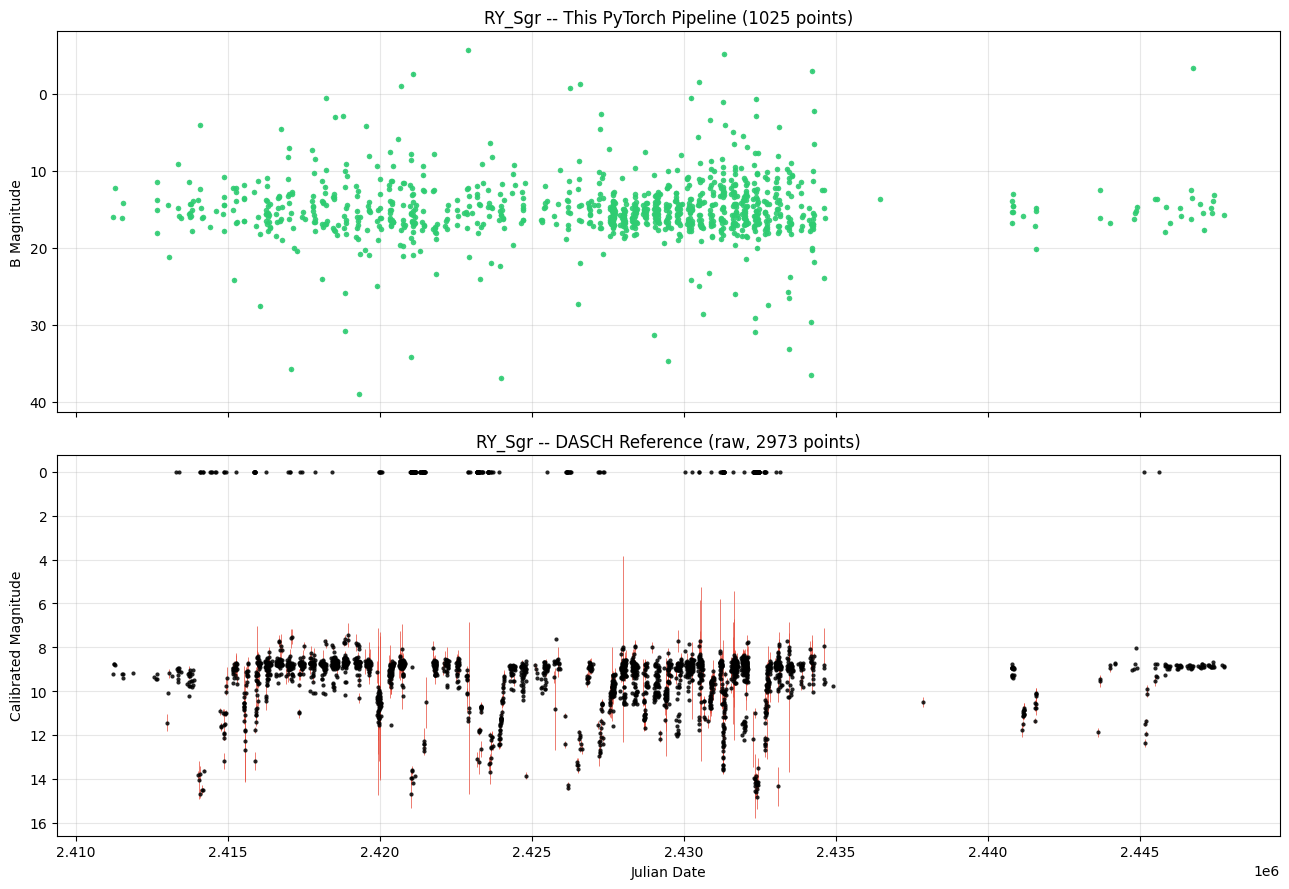

  RY_Sgr target-location tier breakdown:
target_location_tier
apass_list    7003
Opened DASCH session at disk location `C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data\S_Aps`
- Query target: `S Aps`
- Refcat: 8136 sources from `apass`
- Exposures: 8432 relevant exposures


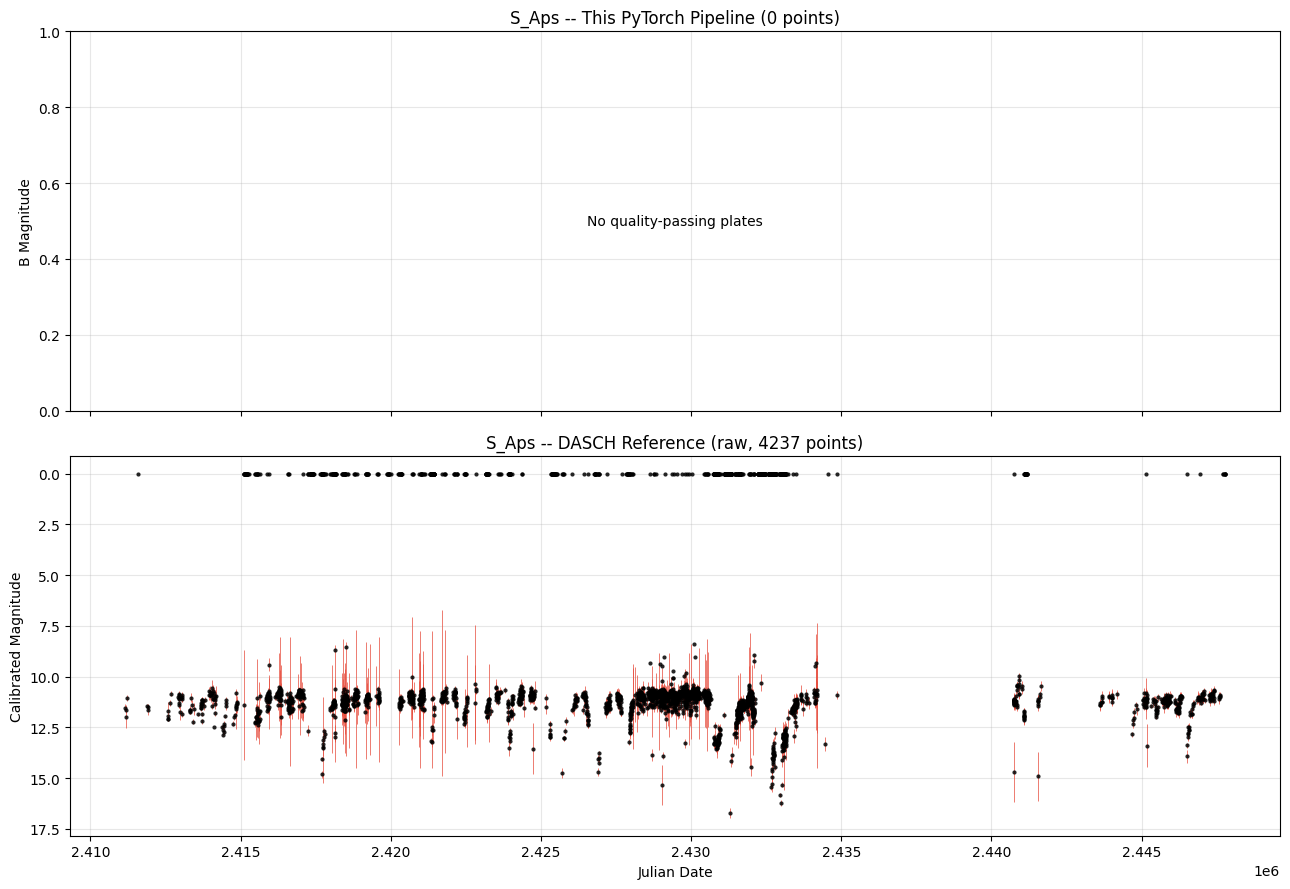

  S_Aps target-location tier breakdown:
target_location_tier
not_found    6820
SU_Tau: no lightcurve.csv found (Cell 1 hasn't been run for this star yet) -- skipping.
U_Aqr: no lightcurve.csv found (Cell 1 hasn't been run for this star yet) -- skipping.
UW_Cen: no lightcurve.csv found (Cell 1 hasn't been run for this star yet) -- skipping.
V2552_Oph: no lightcurve.csv found (Cell 1 hasn't been run for this star yet) -- skipping.
V348_Sgr: no lightcurve.csv found (Cell 1 hasn't been run for this star yet) -- skipping.
V581_CrA: no lightcurve.csv found (Cell 1 hasn't been run for this star yet) -- skipping.
V854_Cen: no lightcurve.csv found (Cell 1 hasn't been run for this star yet) -- skipping.
V_CrA: no lightcurve.csv found (Cell 1 hasn't been run for this star yet) -- skipping.
XX_Cam: no lightcurve.csv found (Cell 1 hasn't been run for this star yet) -- skipping.
Y_Mus: no lightcurve.csv found (Cell 1 hasn't been run for this star yet) -- skipping.

PLOT GENERATION SUMMARY
  star  n_

In [4]:
# NOTE : 03_A_PyTorch.ipynb - Cell 2

# ============================================================================
# Reads each star's saved 03_A/lightcurve.csv and generates the
# This-PyTorch-Pipeline-vs-DASCH comparison plot -- same pattern as
# 02_A_SISaP.ipynb's Cell 2. Fully self-contained (rediscovers star
# folders from disk), can be run independently any time after Cell 1 has
# produced output files, even after a kernel restart.
# ============================================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DATA_DIR = Path(r"C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\data")

star_dirs = sorted([d for d in BASE_DATA_DIR.iterdir()
                     if d.is_dir() and (d / 'cutouts').is_dir()])
print(f"Found {len(star_dirs)} star folders. Generating comparison plots...")

plot_summaries = []

for star_dir in star_dirs:
    lc_path = star_dir / '03_A' / 'lightcurve.csv'
    if not lc_path.exists():
        print(f"{star_dir.name}: no lightcurve.csv found (Cell 1 hasn't been run for this star yet) -- skipping.")
        continue

    lc_df = pd.read_csv(lc_path)

    # --- Fetch DASCH comparison for this star ---
    dasch_jd, dasch_mag, dasch_mag_err = None, None, None
    try:
        from daschlab import Session
        query_name = star_dir.name.replace('_', ' ')

        sess = Session(str(star_dir))
        sess.select_target(query_name)
        sess.select_refcat("apass")
        dlc = sess.lightcurve(0)

        dasch_jd_raw = np.asarray(dlc["time"].jd)
        dasch_mag_raw = np.asarray(dlc["magcal_magdep"].value)
        if "magcal_local_rms" in dlc.colnames:
            dasch_err_raw = np.asarray(dlc["magcal_local_rms"].value)
        else:
            dasch_err_raw = np.full_like(dasch_mag_raw, np.nan)

        good = np.isfinite(dasch_jd_raw) & np.isfinite(dasch_mag_raw)
        dasch_jd, dasch_mag = dasch_jd_raw[good], dasch_mag_raw[good]
        dasch_mag_err = dasch_err_raw[good]
    except Exception as e:
        print(f"  Could not fetch DASCH light curve for {star_dir.name}: {e}")

    # --- Combined comparison plot ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

    if len(lc_df) > 0:
        ax1.errorbar(lc_df['jd'], lc_df['magnitude'], yerr=lc_df['magnitude_error'],
                     fmt='o', color='#2ecc71', markersize=4,
                     ecolor='#16a085', elinewidth=1.0, capsize=1.5, capthick=0.6,
                     alpha=0.9, markeredgewidth=0)
        ax1.invert_yaxis()
    else:
        ax1.text(0.5, 0.5, 'No quality-passing plates', ha='center', va='center', transform=ax1.transAxes)
    ax1.set_ylabel('B Magnitude')
    ax1.set_title(f'{star_dir.name} -- This PyTorch Pipeline ({len(lc_df)} points)')
    ax1.grid(True, alpha=0.3)

    if dasch_jd is not None and len(dasch_jd) > 0:
        ax2.errorbar(dasch_jd, dasch_mag, yerr=dasch_mag_err,
                     fmt='o', color='black', markersize=3,
                     ecolor='#e74c3c', elinewidth=0.6, capsize=1.2, capthick=0.5,
                     alpha=0.85, markeredgewidth=0)
        ax2.invert_yaxis()
        ax2.set_title(f'{star_dir.name} -- DASCH Reference (raw, {len(dasch_jd)} points)')
    else:
        ax2.text(0.5, 0.5, 'DASCH light curve unavailable', ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title(f'{star_dir.name} -- DASCH Reference (unavailable)')
    ax2.set_xlabel('Julian Date')
    ax2.set_ylabel('Calibrated Magnitude')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # --- Target-location tier breakdown (how often the PyTorch tier
    # actually contributed vs. the pre-existing APASS/direct/raw tiers) ---
    results_path = star_dir / '03_A' / 'photometry_results.csv'
    if results_path.exists():
        results_df = pd.read_csv(results_path)
        tier_counts = results_df['target_location_tier'].value_counts()
        print(f"  {star_dir.name} target-location tier breakdown:")
        print(tier_counts.to_string())

    plot_summaries.append({
        'star': star_dir.name,
        'n_pipeline_points': len(lc_df),
        'n_dasch_points': len(dasch_jd) if dasch_jd is not None else 0,
    })

print("\n" + "=" * 70)
print("PLOT GENERATION SUMMARY")
print("=" * 70)
summary_df = pd.DataFrame(plot_summaries)
if len(summary_df) > 0:
    print(summary_df.to_string(index=False))
